**DL_PA2   Roll_Number 25280103:     In this we have to check the model accurac by using the different optimization and genalization techniques: And try to increase the model accuracy by using different methods and techniques**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [35]:
##Loading the data
train_data = np.load("processed_data/quickdraw_train.npz")
test_data = np.load("processed_data/quickdraw_test.npz")

print("Train keys:", train_data.files)
print("Test keys:", test_data.files)

Train keys: ['x_train', 'y_train', 'class_names']
Test keys: ['test_images']


In [36]:
#extract Arrays
# Extract arrays correctly

X_train = train_data['x_train']
y_train = train_data['y_train']
class_names = train_data['class_names']

X_test = test_data['test_images']

print("Train shape:", X_train.shape)
print("Labels shape:", y_train.shape)
print("Test shape:", X_test.shape)
print("Number of classes:", len(class_names))

Train shape: (60000, 784)
Labels shape: (60000,)
Test shape: (15000, 784)
Number of classes: 15


In [37]:
#preprocessing the data for training and testing
# Normalize pixel values to [0,1]

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min value:", X_train.min())
print("Max value:", X_train.max())

Min value: 0.0
Max value: 1.0


In [38]:
# Convert to PyTorch tensors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)

print("Tensor shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

Using device: cpu
Tensor shapes:
X_train: torch.Size([60000, 784])
y_train: torch.Size([60000])
X_test: torch.Size([15000, 784])


In [49]:
#this was giving the 77 to 80% accuracy, now i will use the augmentation to see if it can improve the accuracy
import torchvision.transforms as transforms

# Define augmentation
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor()
])

In [40]:
# Create dataset
dataset = TensorDataset(X_train, y_train)

# 80% train, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)

print("Train size:", train_size)
print("Validation size:", val_size)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train size: 48000
Validation size: 12000
Train batches: 188
Validation batches: 47


""Part 1 Pencake Wise Model where we used the multiple neurons but less number of hidden layers""

In [9]:
# PART A — Pancake Model (Wide, Shallow)

class PancakeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 15)
        )

    def forward(self, x):
        return self.model(x)

pancake = PancakeMLP().to(device)

# Count parameters
total_params = sum(p.numel() for p in pancake.parameters())
print("Pancake parameter count:", total_params)

Pancake parameter count: 1868815


**Model Tranining**
Training Function in which use different types of optimizers and also the lr: 
First used the lr=0.001 and weight decay: 1e-4;    and 35 epchos optimizer used the adam:   
It gave the accuracy 79% and but traning 99 percentage: 

**Model Traning second time and Function**
Decrease the learning rate to 0.0007: increse the capacity:    and weight decay kept same: epochos same:    And used the schedulere optimizer:   same used the batch normalization and also the Gel function and dropout from 0.25 to 0.35: but it gave the accuracy slightly increase to 80% 

**Model Traning 3rd time and optimizations**
Learning rate more decrese used the 0.0005: But still it gave the 80% and used the weight_decay of 5e-4: And epchos 38: In this time i observe that traning increased slowly and also the val increse with it but training went to 99% but the val still quite on the 80%: now im thinking that i should add the regularization and also this time i decreased the data but still it gave the same accuracy: And i also thinking that i should change the optimization techinque this time...

**Model Traning and optimization 4rth time**
This time used the 40 epochs and also use the lr=0.05 and also used the 1million 65k parameters: 

**Model Traning and Optimization 4rth time B**
I minimized the learning rate to 0.0005 in the start it gave the best but after that it still showed 77% result accuracy:


In [ ]:
def train_model(model, epochs=40):

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.0005,
        momentum=0.9,
        weight_decay=5e-4
    )

    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=10,
        gamma=0.1
    )

    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train()
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_acc = correct / total

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total

        scheduler.step()

        print(f"Epoch {epoch+1}: Train={train_acc:.4f}, Val={val_acc:.4f}")

In [11]:
print("Training Pancake Model...")

p_train, p_val = train_model(pancake, epochs=35)                                                                                                                

Training Pancake Model...
Epoch 1: Train=0.6316, Val=0.7044
Epoch 2: Train=0.7357, Val=0.7466
Epoch 3: Train=0.7859, Val=0.7590
Epoch 4: Train=0.8162, Val=0.7718
Epoch 5: Train=0.8483, Val=0.7676
Epoch 6: Train=0.8751, Val=0.7594
Epoch 7: Train=0.9004, Val=0.7595
Epoch 8: Train=0.9208, Val=0.7585
Epoch 9: Train=0.9385, Val=0.7566
Epoch 10: Train=0.9530, Val=0.7590
Epoch 11: Train=0.9618, Val=0.7505
Epoch 12: Train=0.9663, Val=0.7582
Epoch 13: Train=0.9732, Val=0.7613
Epoch 14: Train=0.9757, Val=0.7599
Epoch 15: Train=0.9757, Val=0.7517
Epoch 16: Train=0.9762, Val=0.7578
Epoch 17: Train=0.9836, Val=0.7518
Epoch 18: Train=0.9818, Val=0.7544
Epoch 19: Train=0.9817, Val=0.7521
Epoch 20: Train=0.9859, Val=0.7516
Epoch 21: Train=0.9828, Val=0.7553
Epoch 22: Train=0.9839, Val=0.7525
Epoch 23: Train=0.9857, Val=0.7587
Epoch 24: Train=0.9876, Val=0.7539
Epoch 25: Train=0.9861, Val=0.7562
Epoch 26: Train=0.9871, Val=0.7509
Epoch 27: Train=0.9840, Val=0.7606
Epoch 28: Train=0.9894, Val=0.7602
Epo

**As we used the higher number of so features are memorised by the neurons and in this pancake as multiple nodes used so its giving the less accuracy than the training model sever overfitting....**

**2nd Tower model in this we use the multiple hidden layers and not much the neurons... that's why its called the tower model...**

In [12]:
# PART B — Tower Model (Deep & Narrow)

class TowerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 15)
        )

    def forward(self, x):
        return self.model(x)

tower = TowerMLP().to(device)

print("Tower parameter count:", sum(p.numel() for p in tower.parameters()))

Tower parameter count: 470543


In [13]:
#train Tower model
print("Training Tower Model...")

t_train, t_val = train_model(tower, epochs=35)

Training Tower Model...
Epoch 1: Train=0.6593, Val=0.7175
Epoch 2: Train=0.7455, Val=0.7489
Epoch 3: Train=0.7787, Val=0.7615
Epoch 4: Train=0.8056, Val=0.7655
Epoch 5: Train=0.8263, Val=0.7707
Epoch 6: Train=0.8430, Val=0.7728
Epoch 7: Train=0.8618, Val=0.7702
Epoch 8: Train=0.8746, Val=0.7740
Epoch 9: Train=0.8882, Val=0.7738
Epoch 10: Train=0.9012, Val=0.7682
Epoch 11: Train=0.9091, Val=0.7632
Epoch 12: Train=0.9181, Val=0.7615
Epoch 13: Train=0.9264, Val=0.7669
Epoch 14: Train=0.9367, Val=0.7652
Epoch 15: Train=0.9410, Val=0.7637
Epoch 16: Train=0.9447, Val=0.7668
Epoch 17: Train=0.9519, Val=0.7630
Epoch 18: Train=0.9535, Val=0.7609
Epoch 19: Train=0.9565, Val=0.7596
Epoch 20: Train=0.9610, Val=0.7615
Epoch 21: Train=0.9636, Val=0.7667
Epoch 22: Train=0.9651, Val=0.7610
Epoch 23: Train=0.9658, Val=0.7638
Epoch 24: Train=0.9682, Val=0.7633
Epoch 25: Train=0.9712, Val=0.7661
Epoch 26: Train=0.9715, Val=0.7605
Epoch 27: Train=0.9719, Val=0.7609
Epoch 28: Train=0.9744, Val=0.7662
Epoch

**For the first championFunction used the linear, optiomizaiton BatchnNorm1d, Gelu activation function and also used the dropout 0.3 and data 1.9 nodes: it gave the accuracy of 99% for the test but 79% for the validation:**

In [46]:
class ChampionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 15)
        )

    def forward(self, x):
        return self.model(x)

champion = ChampionMLP().to(device)

print("Champion parameter count:", sum(p.numel() for p in champion.parameters()))

Champion parameter count: 1065999


In [48]:
champion = ChampionMLP().to(device)

print("Training Champion Model...")

c_train, c_val = train_model(champion, epochs=40)

Training Champion Model...
Epoch 1: Train=0.6697, Val=0.7179
Epoch 2: Train=0.7636, Val=0.7415
Epoch 3: Train=0.8020, Val=0.7454
Epoch 4: Train=0.8305, Val=0.7538
Epoch 5: Train=0.8515, Val=0.7426
Epoch 6: Train=0.8710, Val=0.7631
Epoch 7: Train=0.8876, Val=0.7624
Epoch 8: Train=0.8998, Val=0.7602
Epoch 9: Train=0.9154, Val=0.7572
Epoch 10: Train=0.9259, Val=0.7608
Epoch 11: Train=0.9708, Val=0.7837
Epoch 12: Train=0.9865, Val=0.7827
Epoch 13: Train=0.9902, Val=0.7812
Epoch 14: Train=0.9927, Val=0.7816
Epoch 15: Train=0.9938, Val=0.7815
Epoch 16: Train=0.9954, Val=0.7806
Epoch 17: Train=0.9957, Val=0.7803
Epoch 18: Train=0.9967, Val=0.7807
Epoch 19: Train=0.9972, Val=0.7806
Epoch 20: Train=0.9977, Val=0.7797
Epoch 21: Train=0.9985, Val=0.7787
Epoch 22: Train=0.9984, Val=0.7798
Epoch 23: Train=0.9985, Val=0.7778
Epoch 24: Train=0.9984, Val=0.7793
Epoch 25: Train=0.9987, Val=0.7796
Epoch 26: Train=0.9986, Val=0.7796
Epoch 27: Train=0.9986, Val=0.7791
Epoch 28: Train=0.9987, Val=0.7779
Ep

TypeError: cannot unpack non-iterable NoneType object

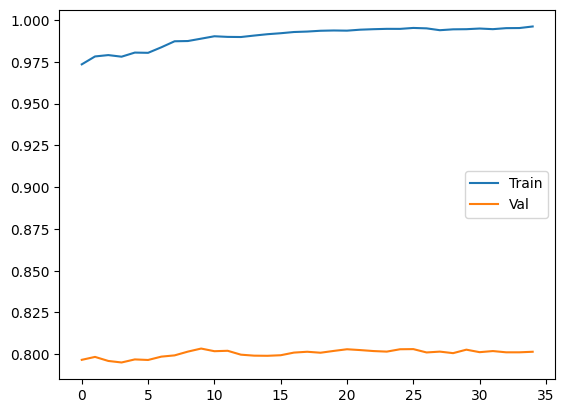

In [ ]:
#Plot Curves
plt.plot(c_train, label="Train")
plt.plot(c_val, label="Val")
plt.legend()
plt.show()

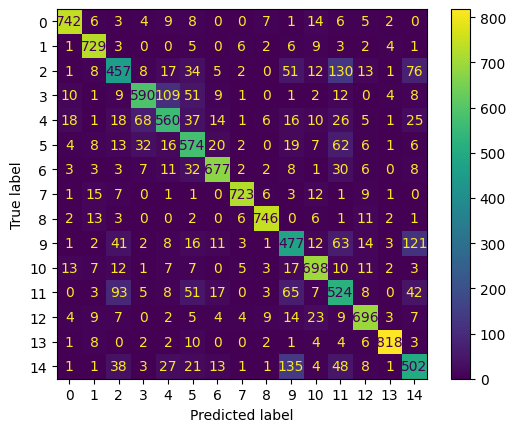

In [17]:
#Confusion Matrix
champion.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in val_loader:
        outputs = champion(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [18]:
#save the bestModel
torch.save(champion.state_dict(), "best_model.pth")

In [19]:
#Generate test prediction
champion.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    outputs = champion(X_test_tensor)
    preds = torch.argmax(outputs, dim=1)

np.savetxt("submission.csv", preds.numpy(), fmt="%d", delimiter=",")

C:\Users\Teacher\AppData\Local\Temp\ipykernel_15580\4027761751.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
